### Activation Functions

Like we know, in a neural network, each neuron receives inputs, computes a weighted sum, adds a bias, and then applies an activation function. 
This function transforms the result into an output signal passed to the next layer.
Without activation functions, even deep networks would behave like simple linear models—unable to capture complex relationships.
Each activation function is used often used in certain type of layers/neuron

Why Are Activation Functions Crucial?
- Non-linearity: Real-world data is rarely linearly separable. Activation functions allow networks to model curved decision boundaries.
- Gradient flow: They enable backpropagation by providing gradients for weight updates.
- Expressiveness: Different functions shape how neurons respond to inputs, influencing learning dynamics and convergence.

⚙️ Common Activation Functions:
- Step : It's a educational function, very rigid, does not support back propagation
- Sigmoid : 
- Tanh	
- ReLU	
- Leaky ReLU	
- Softmax	

### Let's see ach one of them works:

**Step Function**

This is the most simple function based on a threshold. If the input signal is strong enough (≥ 0), it activates. If not, it stays silent. This is the first activation function.  
It works only for binary classification. Does not support Backpropagation, used only in perceptrons.

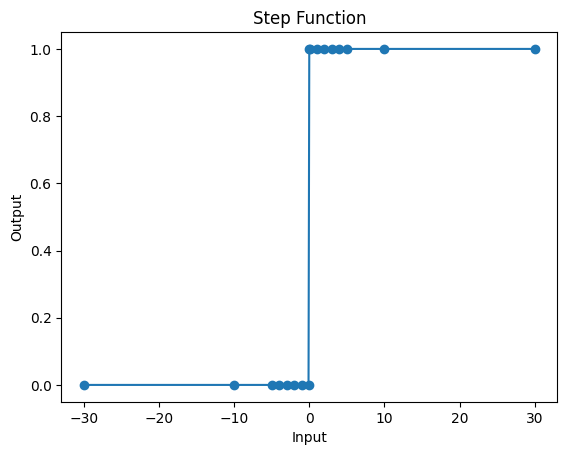

In [37]:
import numpy as np
import matplotlib as plt
import matplotlib.pyplot as plt

numbers = [-30,-10,-5,-4,-3,-2,-1,-0.1,0,0.1,1,2,3,4,5,10,30]

def step_function(x):
    if x >= 0:
        return 1
    else:
        return 0
    
result_step = list(map(step_function, numbers))
plt.plot(numbers, result_step, marker='o')
plt.title('Step Function')
plt.xlabel('Input') 
plt.ylabel('Output')
plt.show()   

**Sigmoid**

The sigmoid activation function maps any input to a value between 0 and 1, creating a smooth S-shaped curve. It's widely used in neural networks to model probabilities and introduce non-linearity.  

**Formula :** 

f(x) = 1 / 1+e**-x       also expressed : 1 divised 1 plus nepero raised at negative X

**When is used:**   
✅ Binary Classification Output: In models like logistic regression or binary neural classifiers  
✅ Hidden Layers (historically) : Used before ReLU became dominant.   
❌ Not ideal for deep hidden layers: ReLU and its variants (Leaky ReLU, ELU) are preferred due to better gradient flow and faster convergence.  

**⚠️ Sigmoid Limitations:**

- Vanishing gradients for large |x|: When the input to the sigmoid is very large or very small, the output saturates near 1 or 0, and the derivative approaches zero. 
          This causes gradients to vanish during backpropagation, especially in deep networks, which can severely slow down or even halt training.
- Non zero-centered output: causes inefficient weight updates and zig-zagging during optimization
- Saturation: compresses wide input ranges into narrow output bands → loss of information
- Numerical instability: exp(-x) overflows for large negative inputs
- Computationally expensive: slower than simpler functions like ReLU
- Poor choice for hidden layers: replaced by ReLU variants in modern deep learning
- Not suitable for multi-class outputs

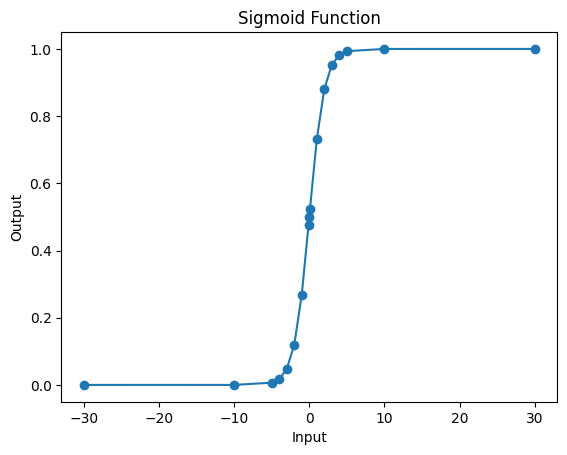

Extreme high sigmoid x, 0.9933071490757153
Extreme low sigmoid x , 0.0066928509242848554


In [38]:
def sigmoid_function(x):
    return 1 / (1 + np.exp(-x))

result_sigmoid = list(map(sigmoid_function, numbers))
plt.plot(numbers, result_sigmoid, marker='o')
plt.title('Sigmoid Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.show()

print("Extreme high sigmoid x,", sigmoid_function(5))
print("Extreme low sigmoid x ,", sigmoid_function(-5))  

**Tanh (Hyperbolic Tangent)**

The tanh activation function maps any input to a value between -1 and 1, creating a smooth S-shaped curve that is symmetric around the origin.  
It is essentially a rescaled version of the sigmoid, but with outputs centered at zero, which often makes optimization more efficient.  

**Formula :**  

f(x) = (e^x - e^-x) / (e^x + e^-x)  
also expressed as: (nepero raised at X minus nepero raised at negative X) divided by (nepero raised at X plus nepero raised at negative X)

**When is used:**  
✅ Hidden Layers (historically): Preferred over sigmoid because it is zero-centered, leading to faster convergence.  
✅ Recurrent Neural Networks (RNNs): Commonly used due to bounded outputs and smooth gradients.  
✅ Feature scaling tasks: Naturally maps values into [-1, 1], useful when normalized data is expected.  
❌ Not ideal for very deep networks: ReLU and its variants are generally preferred for better gradient flow.  

**⚠️ tanh Limitations:**

- Vanishing gradients for large |x|: When the input is very large or very small, the output saturates near -1 or 1, and the derivative approaches zero.  
          This causes gradients to vanish during backpropagation, especially in deep networks, which can severely slow down or even halt training.  
- Computationally expensive: Requires exponentials, slower than simpler functions like ReLU.  
- Saturation: compresses wide input ranges into narrow output bands → loss of information.  
- Still replaced in modern deep learning: ReLU and its variants outperform tanh in most deep architectures.  

**Key Difference from Sigmoid:**  
- Sigmoid outputs in (0, 1) and is not zero-centered.  
- tanh outputs in (-1, 1) and is zero-centered, which usually makes it a better choice for hidden layers in shallow networks.


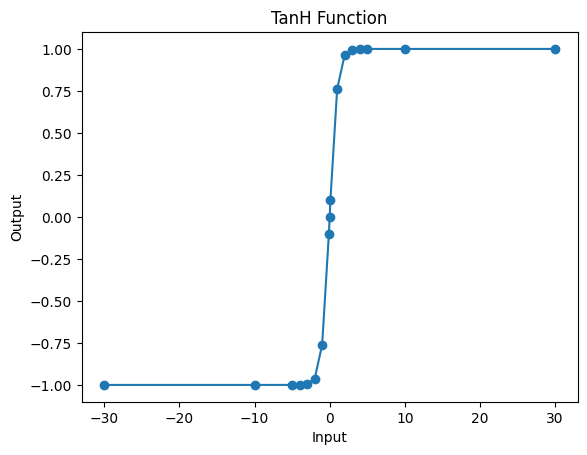

In [39]:
def tanh(x):
    return np.tanh(x)

result_tah = list(map(tanh, numbers))
plt.plot(numbers, result_tah, marker='o')
plt.title('TanH Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.show()

**ReLU (Rectified Linear Unit)**

The ReLU activation function is the most widely used in modern deep learning.  
It introduces non-linearity while remaining computationally simple: it outputs the input directly if it is positive, otherwise it outputs zero.  
This makes networks train faster and helps mitigate the vanishing gradient problem common with sigmoid and tanh.  

**Formula :**  

f(x) = max(0, x)  
also expressed as: if x > 0 → output = x, else output = 0  

**When is used:**  
✅ Hidden Layers in Deep Networks: Default choice in CNNs, MLPs, and many modern architectures.  
✅ Efficient Training: Simple computation, sparse activations, and reduced risk of vanishing gradients.  
✅ Large-Scale Models: Works well with very deep networks where sigmoid/tanh fail.  
❌ Not used for output layers: For classification, softmax or sigmoid are preferred depending on the task.  

**⚠️ ReLU Limitations:**

- **Dying ReLU Problem**: If inputs are always negative, the neuron outputs 0 forever and stops learning.  
- **Unbounded Output**: Positive side grows without limit, which can sometimes cause exploding activations.  
- **Not zero-centered**: Outputs are always ≥ 0, which can still cause some inefficiency in optimization.  
- **Sensitive to learning rate**: Too high a rate can push many neurons into the inactive (zero) region.  

**Variants to Address Limitations:**  
- **Leaky ReLU**: Allows a small slope for negative inputs (e.g., 0.01x instead of 0).  
- **Parametric ReLU (PReLU)**: Learns the slope for negative inputs.  
- **ELU / GELU**: Smooth alternatives that improve gradient flow.  

**Key Difference from Sigmoid and tanh:**  
- Sigmoid → outputs (0, 1), saturates quickly, not zero-centered.  
- tanh → outputs (-1, 1), zero-centered, but still saturates.  
- ReLU → outputs [0, ∞), simple, efficient, avoids vanishing gradients in positive region, and dominates modern deep learning.  


In [ ]:
def ReLU(x):
    return max(0, x)

result_ReLU = list(map(ReLU, numbers))
plt.plot(numbers, result_ReLU, marker='o')
plt.title('ReLU Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.show()

**Leaky ReLU (Leaky Rectified Linear Unit)**

The Leaky ReLU activation function is a variation of the standard ReLU designed to fix its main weakness: the "dying ReLU" problem.  
Instead of outputting exactly 0 for all negative inputs, Leaky ReLU allows a small, non-zero slope on the negative side.  
This ensures that neurons receiving negative inputs still have a gradient and can continue learning.  

**Formula :**  

f(x) = { x, if x > 0  
         α*x, if x ≤ 0 }  

where α is a small constant (commonly 0.01).  

**When is used:**  
✅ Hidden Layers in Deep Networks: Used as an alternative to ReLU to avoid dead neurons.  
✅ Stable Training: Keeps gradients alive even for negative inputs.  
✅ Works well in CNNs, GANs, and deep architectures where ReLU may fail.  
❌ Not typically used in output layers: Softmax or sigmoid are still preferred for classification outputs.  

**⚠️ Leaky ReLU Limitations:**

- **Choice of α matters**: Too small → behaves almost like ReLU; too large → distorts learning.  
- **Not strictly zero-centered**: Negative outputs are small but not symmetric with positive side.  
- **Still unbounded on positive side**: Can lead to exploding activations if not controlled.  
- **Less common default**: While it solves dying ReLU, many architectures still prefer plain ReLU for simplicity unless dead neurons become a problem.  

**Variants:**  
- **Parametric ReLU (PReLU)**: Learns the slope α during training instead of fixing it.  
- **Randomized Leaky ReLU (RReLU)**: Uses a random slope during training for regularization.  

**Key Difference from ReLU:**  
- ReLU → outputs 0 for all negative inputs (risk of dead neurons).  
- Leaky ReLU → allows a small negative slope, keeping gradients alive and improving robustness.  


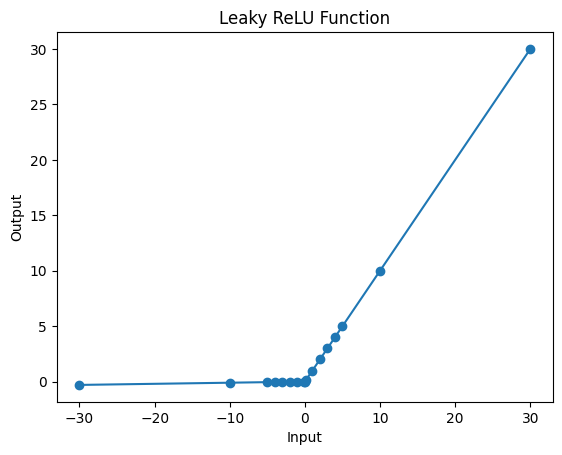

In [41]:
def leaky_ReLU(x):
    return x if x > 0 else 0.01 * x

result_leaky_ReLU = list(map(leaky_ReLU, numbers))
plt.plot(numbers, result_leaky_ReLU, marker='o')
plt.title('Leaky ReLU Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.show()